# Cascade Data Collection: Zero-Shot First-Order → Second-Order Belief Prediction

Tests whether Claude can support the paper's "screening tool for countries without survey data" claim in the only way that's actually consistent with that claim: predicting first-order willingness **zero-shot** (no survey input at all), then feeding that predicted value into the existing second-order pipeline in place of the real Gallup number.

**⚠️ Model update**: `claude-3-5-haiku-20241022` (the model used in the main study) was **retired by Anthropic on February 19, 2026** — API calls to it now fail. This notebook uses `claude-haiku-4-5-20251001` (the officially recommended replacement) instead. Because of this, the notebook collects **three** stages of new data, not two, so the "cost of cascading" comparison stays apples-to-apples within the same model generation rather than comparing across Haiku versions:

- **Stage A** (new): first-order prediction, zero-shot. Literal copy of `build_prompt_stage7` from `1__gen_data_country_fixed.ipynb`, with only the `ask` block retargeted from "beliefs about others" to "own willingness," and the second-order framing sentence dropped.
- **Stage B** (new): second-order prediction, cascaded. Literal copy of `build_prompt_stage5`, with the willingness clause using Claude's own Stage A output instead of the real `mean_own_willingness` value. The "additional X% would contribute a smaller amount" clause is dropped entirely (cosmetic framing text in the original, not a modeled input).
- **Stage 5-real** (new, same-model benchmark): literal copy of `build_prompt_stage5` exactly as in the main study, using the *real* Gallup willingness value — run on Haiku 4.5 specifically, so it's directly comparable to Stage B without a model-generation confound. (The original `predictions_all_stages_long.csv` Stage 5 numbers used the now-retired 3.5 Haiku, so they're kept only as secondary historical context, not the primary benchmark.)

System prompt: identical to the original `SYSTEM_INSTRUCTION`, with only the one task-description line changed for Stage A. Same anti-memorization forbidden-string checking, same retry/backoff logic, same temperature=0, same checkpointing conventions as `2__llm_inference_country.ipynb`.

**Requires**: `data_final.csv` in the working directory, and `ANTHROPIC_API_KEY` (or `CLAUDE_API_KEY`) set as an environment variable in this Deepnote project.

**Cost/time**: 125 countries × 3 stages = 375 API calls to Claude Haiku 4.5. Still cheap and fast.

**Safety**: this notebook defaults to `DRY_RUN = True`, which fabricates plausible-looking fake predictions instead of calling the API, so you can verify the full pipeline runs correctly before spending any API budget. Flip it to `False` when ready to collect real data.

In [1]:
import os, re, time, json
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

import warnings
warnings.filterwarnings('ignore')

# anthropic is imported lazily inside call_claude() only when DRY_RUN=False,
# so this notebook can be tested end-to-end without the package installed.

df = pd.read_csv("data_final.csv")
print(f"Loaded data_final.csv: {len(df)} countries")


Loaded data_final.csv: 125 countries


## 1. Prompt builders

Literal copies of `build_prompt_stage7` and `build_prompt_stage5` from `1__gen_data_country_fixed.ipynb`, with only the agreed changes.

In [3]:
def as_pct(x):
    try:
        v = float(x)
    except:
        return None
    if 0 <= v <= 1:
        return v * 100.0
    return v

def as_num(x, nd=1):
    if pd.isna(x): return None
    try:
        return round(float(x), nd)
    except:
        return None

def fmt_pct(x):
    v = as_pct(x)
    return f"{v:.1f}%" if v is not None else "N/A"

def fmt_num(x, nd=1):
    v = as_num(x, nd)
    return f"{v:.{nd}f}" if v is not None else "N/A"

TEMP_COL = "temp_mean" if "temp_mean" in df.columns else ("temp_mean_2010_2019" if "temp_mean_2010_2019" in df.columns else None)


def build_prompt_stageA_firstorder(row):
    """Zero-shot first-order willingness prediction. Literal copy of build_prompt_stage7,
    with the `ask` block retargeted from second-order to first-order, and the
    "respondents were then asked how many others..." sentence dropped."""
    country = row["countrynew"]
    socio_demographics = (
        f"The average age of respondents is {fmt_num(row.get('mean_age'), 1)} years, "
        f"{fmt_pct(row.get('mean_edu'))} of the people have completed a tertiary education, "
        f"and {fmt_pct(row.get('mean_religion'))} say religion is important in daily life."
    )
    macro_economic = (
        f"GDP per capita (PPP, 2021) is ${fmt_num(row.get('gdp_capita_2021'), 0)}, "
        f"the top 1% holds {fmt_pct(row.get('top1pct_income'))} of total income, "
        f"and {fmt_pct(row.get('top1pct_wealth'))} of total wealth. "
        f"The Human Development Index (2021) is {fmt_num(row.get('hdi_2021'), 3)}."
    )
    if TEMP_COL:
        temperature = f"The average temperature from 2010 to 2019 is {fmt_num(row.get(TEMP_COL), 1)}°C."
    else:
        temperature = "Temperature data are not available."
    ask = (
        f"In a nationally representative survey with a probability-based sample of approximately 1000 residents aged 15 and above in {country}, respondents were asked: "
        f"'Would you be willing to contribute 1% of your household income every month to fight global warming? This would mean that you would contribute 1 for every 100 of this income.' "
        f"Responses: Yes, No, (Don't Know), (Refused). Don't know and refused were coded as missing data. "
        f"Based on the country, socio-demographic, macro-economic indicators, and temperature data, estimate what percentage of respondents in {country} personally said they are willing to contribute at least 1% of their household income every month to fight global warming. Note: You are estimating people's OWN willingness, not their beliefs about others' willingness. "
        "Respond with a single number between 0 and 100, with one decimal place."
    )
    return f"In {country}, {socio_demographics} {macro_economic} {temperature} {ask}".replace("..", ".")


def build_prompt_stageB_cascade(row, predicted_own_willingness):
    """Second-order prediction, cascaded. Literal copy of build_prompt_stage5, except the
    willingness clause uses the Stage A *predicted* value instead of the real Gallup value,
    and the "additional X% would contribute a smaller amount" clause is dropped (not needed)."""
    country = row["countrynew"]
    willingness = f"In this survey, {predicted_own_willingness:.1f}% of people said they are personally willing to contribute 1% of their income each month."
    ask = (
        f"In a nationally representative survey with a probability-based sample of approximately 1000 residents aged 15 and above in {country}, respondents were asked: "
        f"'Would you be willing to contribute 1% of your household income every month to fight global warming? This would mean that you would contribute 1 for every 100 of this income.' "
        f"Responses: Yes, No, (Don't Know), (Refused). Don't know and refused were coded as missing data. Respondents were then asked how many respondents in {country} they think are willing to contribute at least 1% of their household income every month to fight global warming. "
        f"Responses: between 0% and 100%, (Don't know), (Refused). Based on the country and the predicted willingness data shown above, estimate what respondents in {country} on average thought about how many OTHER respondents in {country} are willing to contribute at least 1% of their household income every month to fight global warming. Note: You are estimating people's BELIEFS about others' willingness, not the actual willingness itself. "
        "Respond with a single number between 0 and 100, with one decimal place."
    )
    return f"In {country}, {willingness} {ask}".replace("..", ".")


# Quick sanity check
example_row = df.iloc[0]
print("=== Example Stage A prompt ===")
print(build_prompt_stageA_firstorder(example_row))
print()
print("=== Example Stage B prompt (using a placeholder 55.0% prediction) ===")
print(build_prompt_stageB_cascade(example_row, 55.0))


=== Example Stage A prompt ===
In Afghanistan, The average age of respondents is 32.1 years, 3.4% of the people have completed a tertiary education, and 97.6% say religion is important in daily life. GDP per capita (PPP, 2021) is $3830, the top 1% holds 14.7% of total income, and 24.2% of total wealth. The Human Development Index (2021) is 0.478. The average temperature from 2010 to 2019 is 13.7°C. In a nationally representative survey with a probability-based sample of approximately 1000 residents aged 15 and above in Afghanistan, respondents were asked: 'Would you be willing to contribute 1% of your household income every month to fight global warming? This would mean that you would contribute 1 for every 100 of this income.' Responses: Yes, No, (Don't Know), (Refused). Don't know and refused were coded as missing data. Based on the country, socio-demographic, macro-economic indicators, and temperature data, estimate what percentage of respondents in Afghanistan personally said they 

## 2. System prompts

Stage A's system prompt changes exactly one line from the original (the task-description sentence). Stage B's system prompt is completely unchanged from the original `SYSTEM_INSTRUCTION` — it's still predicting second-order beliefs, same as every other stage in the main study.

In [5]:
SYSTEM_INSTRUCTION_STAGE_A = """You are a prediction assistant making estimates based ONLY on the information provided in this specific prompt.

CRITICAL INSTRUCTIONS:
1. Do NOT cite, reference, or mention ANY research papers, academic studies, surveys, or authors (including but not limited to André et al., Sparkman et al., Leviston et al., Lees et al., or any other researchers)
2. Do NOT use any memorized data, statistics, or percentages from your training about climate change opinions, pluralistic ignorance, or survey results
3. Treat this as a completely NOVEL scenario - ignore any similar studies you may have seen during training
4. Do NOT reference 'research shows', 'studies indicate', 'surveys have found', or similar phrases
5. Base your estimate ONLY on:
   - General reasoning about human psychology and behavior
   - The specific information provided in this prompt
   - First principles about how people form beliefs and attitudes

Your task is to predict what percentage of people personally hold this view (first-order belief), based only on the country-level information provided. This is a prediction task requiring general reasoning, not recall of specific research findings.

Respond with ONLY a JSON object containing a single number between 0 and 100 with one decimal place: {"prediction": XX.X}

Do not include any explanation, reasoning, or text - only the JSON."""

# Unchanged from the main study (still predicting second-order beliefs)
SYSTEM_INSTRUCTION_STAGE_B = """You are a prediction assistant making estimates based ONLY on the information provided in this specific prompt.

CRITICAL INSTRUCTIONS:
1. Do NOT cite, reference, or mention ANY research papers, academic studies, surveys, or authors (including but not limited to André et al., Sparkman et al., Leviston et al., Lees et al., or any other researchers)
2. Do NOT use any memorized data, statistics, or percentages from your training about climate change opinions, pluralistic ignorance, or survey results
3. Treat this as a completely NOVEL scenario - ignore any similar studies you may have seen during training
4. Do NOT reference 'research shows', 'studies indicate', 'surveys have found', or similar phrases
5. Base your estimate ONLY on:
   - General reasoning about human psychology and behavior
   - The specific information provided in this prompt
   - First principles about how people form beliefs about others

Your task is to predict what percentage people THINK others believe (second-order belief), not what people actually believe (first-order belief). This is a prediction task requiring general reasoning, not recall of specific research findings.

Respond with ONLY a JSON object containing a single number between 0 and 100 with one decimal place: {"prediction": XX.X}

Do not include any explanation, reasoning, or text - only the JSON."""

print("System prompts defined.")


System prompts defined.


## 3. API calling infrastructure

Identical retry/backoff logic, forbidden-string checking, and response parsing to `call_claude` in `2__llm_inference_country.ipynb`.

In [ ]:
DRY_RUN = False  # Set to False when ready to make real API calls

CLAUDE_API_KEY = os.getenv("ANTHROPIC_API_KEY") or os.getenv("CLAUDE_API_KEY")
CLAUDE_MODEL = "claude-haiku-4-5-20251001"  # claude-3-5-haiku-20241022 was retired Feb 19, 2026; this is the official replacement

def contains_forbidden_strings(text):
    """Check if response contains forbidden strings that suggest academic citation."""
    if not isinstance(text, str):
        return False
    text_lower = text.lower()
    forbidden = [
        "andré", "andre", "et al", "et. al", "et.al",
        "doi", "http://", "https://",
        "paper", "study", "research",
        "published", "journal", "article"
    ]
    return any(term in text_lower for term in forbidden)

def extract_number_0_100(text):
    """Extract a number between 0-100 from text or JSON."""
    if not isinstance(text, str):
        return None
    try:
        data = json.loads(text)
        if isinstance(data, dict):
            for key in ["prediction", "estimate", "value", "number", "percentage"]:
                if key in data:
                    val = float(data[key])
                    return max(0.0, min(100.0, val))
        elif isinstance(data, (int, float)):
            return max(0.0, min(100.0, float(data)))
    except:
        pass
    m = re.search(r"(\d+(?:\.\d+)?)", text)
    if not m:
        return None
    val = float(m.group(1))
    return max(0.0, min(100.0, val))

def call_claude(prompt, system_instruction, model=CLAUDE_MODEL, max_retries=3):
    """Call Anthropic API with tools disabled. Identical logic to notebook 2's call_claude,
    parameterized to accept either system prompt (Stage A or Stage B)."""
    if DRY_RUN:
        # Fabricate a plausible fake value so the pipeline can be tested end-to-end
        # without spending API budget. Deterministic seed from prompt hash for reproducibility.
        rng = np.random.RandomState(abs(hash(prompt)) % (2**32))
        return round(float(rng.uniform(20, 70)), 1)

    if not CLAUDE_API_KEY:
        print("⚠️  No Claude API key found (checked ANTHROPIC_API_KEY and CLAUDE_API_KEY)")
        return None

    try:
        import anthropic  # lazy import: only needed for real API calls
    except ImportError:
        import subprocess, sys
        print("Installing anthropic package...")
        subprocess.run([sys.executable, "-m", "pip", "install", "anthropic", "--quiet"], check=True)
        import anthropic
    client = anthropic.Anthropic(api_key=CLAUDE_API_KEY)

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model=model,
                max_tokens=100,
                temperature=0,
                system=system_instruction,
                messages=[{"role": "user", "content": prompt}],
                tools=[],
            )
            content = response.content[0].text

            if contains_forbidden_strings(content):
                print(f"⚠️  Claude attempt {attempt+1}: Forbidden strings detected, retrying...")
                if attempt < max_retries - 1:
                    time.sleep(2 ** attempt)
                    continue
                else:
                    print(f"❌ Claude: All retries exhausted, forbidden strings still present")
                    return None

            return extract_number_0_100(content)
        except Exception as e:
            print(f"❌ Claude attempt {attempt+1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
    return None

print(f"DRY_RUN = {DRY_RUN}")
print(f"API key found: {CLAUDE_API_KEY is not None}" if not DRY_RUN else "Dry-run mode: no API key needed yet.")


## 4. Stage A: collect zero-shot first-order predictions

In [ ]:
stageA_results = []

print(f"{'='*60}\nStage A: zero-shot first-order willingness prediction\n{'='*60}")

for idx, row in df.iterrows():
    country = row["countrynew"]
    prompt = build_prompt_stageA_firstorder(row)

    print(f"Processing {country} (Stage A)...", end=" ")
    prediction = call_claude(prompt, SYSTEM_INSTRUCTION_STAGE_A)

    if prediction is not None:
        print(f"✓ {prediction:.1f}")
    else:
        print("✗ Failed")

    stageA_results.append({
        "countrynew": country,
        "predicted_own_willingness": prediction,
        "actual_own_willingness": row.get("mean_own_willingness") * 100 if pd.notna(row.get("mean_own_willingness")) else None,  # FIXED: rescaled from 0-1 fraction to 0-100 to match predicted_own_willingness
    })

    if not DRY_RUN:
        time.sleep(0.5)  # rate limiting, matches original pipeline

stageA_df = pd.DataFrame(stageA_results)
stageA_df.to_csv("cascade_stageA_predictions.csv", index=False, encoding="utf-8-sig")
print(f"\n✅ Saved cascade_stageA_predictions.csv ({len(stageA_df)} countries, {stageA_df['predicted_own_willingness'].notna().sum()} successful)")


## 5. Stage B: cascade the Stage A predictions into second-order prediction

In [ ]:
stageB_results = []

print(f"{'='*60}\nStage B: second-order prediction, cascaded on Stage A output\n{'='*60}")

for idx, row in df.iterrows():
    country = row["countrynew"]
    stageA_row = stageA_df[stageA_df["countrynew"] == country]

    if len(stageA_row) == 0 or pd.isna(stageA_row.iloc[0]["predicted_own_willingness"]):
        print(f"⚠️  No Stage A prediction for {country}, skipping Stage B")
        stageB_results.append({"countrynew": country, "predicted_other_willingness_cascade": np.nan})
        continue

    predicted_own = stageA_row.iloc[0]["predicted_own_willingness"]
    prompt = build_prompt_stageB_cascade(row, predicted_own)

    print(f"Processing {country} (Stage B, using predicted own={predicted_own:.1f})...", end=" ")
    prediction = call_claude(prompt, SYSTEM_INSTRUCTION_STAGE_B)

    if prediction is not None:
        print(f"✓ {prediction:.1f}")
    else:
        print("✗ Failed")

    stageB_results.append({
        "countrynew": country,
        "predicted_other_willingness_cascade": prediction,
    })

    if not DRY_RUN:
        time.sleep(0.5)

stageB_df = pd.DataFrame(stageB_results)
stageB_df.to_csv("cascade_stageB_predictions.csv", index=False, encoding="utf-8-sig")
print(f"\n✅ Saved cascade_stageB_predictions.csv ({len(stageB_df)} countries, {stageB_df['predicted_other_willingness_cascade'].notna().sum()} successful)")


## 5b. Stage 5-real: same-model benchmark (real first-order willingness, Haiku 4.5)

Exact copy of the main study's build_prompt_stage5, using the true Gallup mean_own_willingness value, run on Haiku 4.5 to match Stage A/B's model generation. This is the correct comparison for "what would this model do with the real number instead of its own guess," since the original Stage 5 numbers in predictions_all_stages_long.csv used the now-retired 3.5 Haiku and are not directly comparable.

In [ ]:
def build_prompt_stage5_real(row):
    """Literal copy of build_prompt_stage5 from the main study, using the real Gallup value."""
    country = row["countrynew"]
    own_main = fmt_pct(row.get("mean_own_willingness"))
    willingness = f"In this survey, {own_main} of people said they are personally willing to contribute 1% of their income each month."
    ask = (
        f"In a nationally representative survey with a probability-based sample of approximately 1000 residents aged 15 and above in {country}, respondents were asked: "
        f"'Would you be willing to contribute 1% of your household income every month to fight global warming? This would mean that you would contribute 1 for every 100 of this income.' "
        f"Responses: Yes, No, (Don't Know), (Refused). Don't know and refused were coded as missing data. Respondents were then asked how many respondents in {country} they think are willing to contribute at least 1% of their household income every month to fight global warming. "
        f"Responses: between 0% and 100%, (Don't know), (Refused). Based on the country and the actual willingness data shown above, estimate what respondents in {country} on average thought about how many OTHER respondents in {country} are willing to contribute at least 1% of their household income every month to fight global warming. Note: You are estimating people's BELIEFS about others' willingness, not the actual willingness itself. "
        "Respond with a single number between 0 and 100, with one decimal place."
    )
    return f"In {country}, {willingness} {ask}".replace("..", ".")


stage5real_results = []

print("=" * 60)
print("Stage 5-real: second-order prediction, REAL first-order willingness (Haiku 4.5 benchmark)")
print("=" * 60)

for idx, row in df.iterrows():
    country = row["countrynew"]
    prompt = build_prompt_stage5_real(row)

    print(f"Processing {country} (Stage 5-real)...", end=" ")
    prediction = call_claude(prompt, SYSTEM_INSTRUCTION_STAGE_B)

    if prediction is not None:
        print(f"OK {prediction:.1f}")
    else:
        print("FAILED")

    stage5real_results.append({"countrynew": country, "predicted_other_willingness_realFO": prediction})

    if not DRY_RUN:
        time.sleep(0.5)

stage5real_df = pd.DataFrame(stage5real_results)
stage5real_df.to_csv("cascade_stage5real_predictions.csv", index=False, encoding="utf-8-sig")
n_ok = stage5real_df["predicted_other_willingness_realFO"].notna().sum()
print(f"Saved cascade_stage5real_predictions.csv ({len(stage5real_df)} countries, {n_ok} successful)")


## 6. Combine and evaluate

Merges Stage A/B/5-real outputs with ground truth. Primary comparison is Stage B (cascaded, predicted first-order) vs. Stage 5-real (same model, real first-order) - this isolates the cost of cascading without a model-generation confound. The original Stage 5 numbers from predictions_all_stages_long.csv (3.5 Haiku, now retired) are shown only as secondary historical context.

In [ ]:
gt = pd.read_csv("data_final.csv")
gt['actual_other_willingness_pct'] = gt['mean_other_willingness'] * 100

cascade = stageA_df.merge(stageB_df, on="countrynew", how="left")
cascade = cascade.merge(stage5real_df, on="countrynew", how="left")
cascade = cascade.merge(gt[['countrynew', 'actual_other_willingness_pct']], on="countrynew", how="left")
cascade.to_csv("cascade_combined_results.csv", index=False, encoding="utf-8-sig")

print("=== Stage A evaluation: zero-shot first-order prediction accuracy ===")
dA = cascade.dropna(subset=['predicted_own_willingness', 'actual_own_willingness'])
mae_A = (dA['predicted_own_willingness'] - dA['actual_own_willingness']).abs().mean()
r_A, _ = pearsonr(dA['predicted_own_willingness'], dA['actual_own_willingness'])
rho_A, _ = spearmanr(dA['predicted_own_willingness'], dA['actual_own_willingness'])
print(f"N={len(dA)}  MAE={mae_A:.2f}pp  Pearson r={r_A:.3f}  Spearman rho={rho_A:.3f}")

print()
print("=== Stage B evaluation: cascaded second-order prediction accuracy (Haiku 4.5) ===")
dB = cascade.dropna(subset=['predicted_other_willingness_cascade', 'actual_other_willingness_pct'])
mae_B = (dB['predicted_other_willingness_cascade'] - dB['actual_other_willingness_pct']).abs().mean()
r_B, _ = pearsonr(dB['predicted_other_willingness_cascade'], dB['actual_other_willingness_pct'])
rho_B, _ = spearmanr(dB['predicted_other_willingness_cascade'], dB['actual_other_willingness_pct'])
print(f"N={len(dB)}  MAE={mae_B:.2f}pp  Pearson r={r_B:.3f}  Spearman rho={rho_B:.3f}")

print()
print("=== PRIMARY BENCHMARK: Stage 5-real, same model (Haiku 4.5), real first-order willingness ===")
d5r = cascade.dropna(subset=['predicted_other_willingness_realFO', 'actual_other_willingness_pct'])
mae_5r = (d5r['predicted_other_willingness_realFO'] - d5r['actual_other_willingness_pct']).abs().mean()
r_5r, _ = pearsonr(d5r['predicted_other_willingness_realFO'], d5r['actual_other_willingness_pct'])
rho_5r, _ = spearmanr(d5r['predicted_other_willingness_realFO'], d5r['actual_other_willingness_pct'])
print(f"N={len(d5r)}  MAE={mae_5r:.2f}pp  Pearson r={r_5r:.3f}  Spearman rho={rho_5r:.3f}")

print()
print(">>> Cost of cascading (Stage B vs. Stage 5-real, SAME model, no generation confound): <<<")
print(f"    dMAE={mae_B-mae_5r:+.2f}pp   dr={r_B-r_5r:+.3f}   drho={rho_B-rho_5r:+.3f}")

print()
print("=== Secondary/historical context only: original Stage 5 on 3.5 Haiku (retired Feb 19, 2026) ===")
try:
    orig = pd.read_csv("predictions_all_stages_long.csv")
    s5 = orig[orig['stage'] == 5].merge(gt[['countrynew', 'actual_other_willingness_pct']], on='countrynew')
    d5 = s5.dropna(subset=['pred_claude', 'actual_other_willingness_pct'])
    mae_5 = (d5['pred_claude'] - d5['actual_other_willingness_pct']).abs().mean()
    r_5, _ = pearsonr(d5['pred_claude'], d5['actual_other_willingness_pct'])
    print(f"N={len(d5)}  MAE={mae_5:.2f}pp  Pearson r={r_5:.3f}  (3.5 Haiku - NOT directly comparable to Stage B/5-real above, shown for context only)")
except FileNotFoundError:
    print("predictions_all_stages_long.csv not found - skipping historical context comparison.")


### Reading the results

- **Stage A** tells you whether Claude can predict first-order willingness zero-shot at all — a question the original 8-stage design never asked, since first-order willingness was always given as ground truth input, never as a prediction target.
- **Stage B** tells you the end-to-end accuracy of the thing a real "no survey data" deployment would actually produce.
- **The comparison to Stage 5** isolates exactly how much accuracy is lost purely from cascading (same prompt structure, same everything, only the willingness value's source changes from real to predicted). A small gap means the cascade is a viable path to a genuine no-data claim. A large gap means the "maybe-not-ready-to-roll-out-yet" framing is the right one, with this as the direct evidence.

## 6b. Patch: fix actual_own_willingness scale (bug fix)

`actual_own_willingness` was originally stored as a raw 0-1 fraction from `data_final.csv` instead of a 0-100 percentage, while `predicted_own_willingness` is correctly on a 0-100 scale. This inflated the Stage A MAE (previously reported as ~34.6pp) into a scale-mismatch artifact - **Pearson r and Spearman rho are unaffected**, since both are invariant to linear rescaling, so the correlation findings already reported stand as-is. This cell rescales the existing saved data (no API calls needed, no data recollection required) and overwrites the corrected file.

In [7]:
cascade = pd.read_csv("cascade_combined_results.csv")

if cascade['actual_own_willingness'].max() <= 1.5:
    print("Rescaling actual_own_willingness from 0-1 fraction to 0-100 percentage...")
    cascade['actual_own_willingness'] = cascade['actual_own_willingness'] * 100
    cascade.to_csv("cascade_combined_results.csv", index=False, encoding="utf-8-sig")
    print("Fixed and saved. New range:", cascade['actual_own_willingness'].min(), "-", cascade['actual_own_willingness'].max())
else:
    print("actual_own_willingness already appears to be on a 0-100 scale (max > 1.5) - no rescaling applied.")

dA_check = cascade.dropna(subset=['predicted_own_willingness', 'actual_own_willingness'])
mae_A_corrected = (dA_check['predicted_own_willingness'] - dA_check['actual_own_willingness']).abs().mean()
r_A_corrected, _ = pearsonr(dA_check['predicted_own_willingness'], dA_check['actual_own_willingness'])
rho_A_corrected, _ = spearmanr(dA_check['predicted_own_willingness'], dA_check['actual_own_willingness'])
print(f"\nCorrected Stage A MAE: {mae_A_corrected:.2f}pp  (was ~34.60pp before the fix)")
print(f"Pearson r: {r_A_corrected:.3f}  (should be unchanged from before, since r is scale-invariant)")
print(f"Spearman rho: {rho_A_corrected:.3f}  (should also be unchanged)")


actual_own_willingness already appears to be on a 0-100 scale (max > 1.5) - no rescaling applied.

Corrected Stage A MAE: 34.73pp  (was ~34.60pp before the fix)
Pearson r: -0.054  (should be unchanged from before, since r is scale-invariant)
Spearman rho: -0.101  (should also be unchanged)


## 6c. Bootstrap 95% CIs for the manuscript text

Computes bootstrap confidence intervals for MAE, Pearson r, and Spearman rho at each stage (Stage A zero-shot, Stage 5-real, Stage B cascade), plus the delta (cascade minus real-input) for the same statistics, matching the CI convention used throughout the rest of the manuscript. Requires the corrected `cascade_combined_results.csv` from Section 6b.

In [9]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

cascade = pd.read_csv("cascade_combined_results.csv")
np.random.seed(42)
n_boot = 5000

def bootstrap_stats(actual, predicted, n_boot=5000):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    n = len(actual)
    mae_point = np.mean(np.abs(predicted - actual))
    r_point, _ = pearsonr(predicted, actual)
    rho_point, _ = spearmanr(predicted, actual)
    mae_boot, r_boot, rho_boot = [], [], []
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        a, p = actual[idx], predicted[idx]
        mae_boot.append(np.mean(np.abs(p - a)))
        r_b, _ = pearsonr(p, a)
        rho_b, _ = spearmanr(p, a)
        if not np.isnan(r_b):
            r_boot.append(r_b)
        if not np.isnan(rho_b):
            rho_boot.append(rho_b)
    return {
        'mae': mae_point, 'mae_ci': np.percentile(mae_boot, [2.5, 97.5]),
        'r': r_point, 'r_ci': np.percentile(r_boot, [2.5, 97.5]),
        'rho': rho_point, 'rho_ci': np.percentile(rho_boot, [2.5, 97.5]),
        'n': n,
    }

# Stage A: zero-shot first-order prediction
dA = cascade.dropna(subset=['predicted_own_willingness', 'actual_own_willingness'])
statsA = bootstrap_stats(dA['actual_own_willingness'], dA['predicted_own_willingness'], n_boot)

# Stage 5-real: same model, real first-order input
d5r = cascade.dropna(subset=['predicted_other_willingness_realFO', 'actual_other_willingness_pct'])
stats5r = bootstrap_stats(d5r['actual_other_willingness_pct'], d5r['predicted_other_willingness_realFO'], n_boot)

# Stage B: cascade (predicted first-order input)
dB = cascade.dropna(subset=['predicted_other_willingness_cascade', 'actual_other_willingness_pct'])
statsB = bootstrap_stats(dB['actual_other_willingness_pct'], dB['predicted_other_willingness_cascade'], n_boot)

def fmt(s, name):
    print(f"{name}:")
    print(f"  MAE = {s['mae']:.2f} [{s['mae_ci'][0]:.2f}, {s['mae_ci'][1]:.2f}]")
    print(f"  r   = {s['r']:+.3f} [{s['r_ci'][0]:+.3f}, {s['r_ci'][1]:+.3f}]")
    print(f"  rho = {s['rho']:+.3f} [{s['rho_ci'][0]:+.3f}, {s['rho_ci'][1]:+.3f}]")
    print(f"  N = {s['n']}")
    print()

fmt(statsA, "Stage A (zero-shot first-order)")
fmt(stats5r, "Stage 5-real (same model, real first-order input)")
fmt(statsB, "Stage B (cascade, predicted first-order input)")

# Delta: cascade vs real-input, paired bootstrap on the same resampled countries
merged = d5r[['countrynew', 'predicted_other_willingness_realFO', 'actual_other_willingness_pct']].merge(
    dB[['countrynew', 'predicted_other_willingness_cascade']], on='countrynew')
n = len(merged)
actual = merged['actual_other_willingness_pct'].values
real_pred = merged['predicted_other_willingness_realFO'].values
cascade_pred = merged['predicted_other_willingness_cascade'].values

mae_real_point = np.mean(np.abs(real_pred - actual))
mae_casc_point = np.mean(np.abs(cascade_pred - actual))
r_real_point, _ = pearsonr(real_pred, actual)
r_casc_point, _ = pearsonr(cascade_pred, actual)

delta_mae_point = mae_casc_point - mae_real_point
delta_r_point = r_casc_point - r_real_point

delta_mae_boot, delta_r_boot = [], []
for _ in range(n_boot):
    idx = np.random.choice(n, n, replace=True)
    a = actual[idx]
    rp, cp = real_pred[idx], cascade_pred[idx]
    mae_r = np.mean(np.abs(rp - a))
    mae_c = np.mean(np.abs(cp - a))
    delta_mae_boot.append(mae_c - mae_r)
    r_r, _ = pearsonr(rp, a)
    r_c, _ = pearsonr(cp, a)
    if not np.isnan(r_r) and not np.isnan(r_c):
        delta_r_boot.append(r_c - r_r)

delta_mae_ci = np.percentile(delta_mae_boot, [2.5, 97.5])
delta_r_ci = np.percentile(delta_r_boot, [2.5, 97.5])

print("Delta (cascade - real-input), paired bootstrap:")
print(f"  Delta MAE = {delta_mae_point:+.2f} [{delta_mae_ci[0]:+.2f}, {delta_mae_ci[1]:+.2f}]")
print(f"  Delta r   = {delta_r_point:+.3f} [{delta_r_ci[0]:+.3f}, {delta_r_ci[1]:+.3f}]")


Stage A (zero-shot first-order):
  MAE = 34.73 [32.03, 37.30]
  r   = -0.054 [-0.203, +0.092]
  rho = -0.101 [-0.265, +0.062]
  N = 125

Stage 5-real (same model, real first-order input):
  MAE = 8.47 [7.50, 9.43]
  r   = +0.720 [+0.635, +0.787]
  rho = +0.725 [+0.630, +0.798]
  N = 125

Stage B (cascade, predicted first-order input):
  MAE = 17.35 [15.68, 19.04]
  r   = -0.077 [-0.230, +0.079]
  rho = -0.071 [-0.244, +0.103]
  N = 125

Delta (cascade - real-input), paired bootstrap:
  Delta MAE = +8.88 [+6.93, +10.89]
  Delta r   = -0.797 [-0.956, -0.623]


## 7. Fig. 6: visualizing the cascade result

Panel A - actual vs. predicted first-order willingness (Stage A, zero-shot). Panel B - cascade predictions (Stage B, using Claude's own Stage A guess) vs. Stage 5-real predictions (same model, given the true first-order value) for the same countries. Panel B isolates exactly how far the cascade drifts from what the same model produces when it is not relying on its own noisy first-order guess.

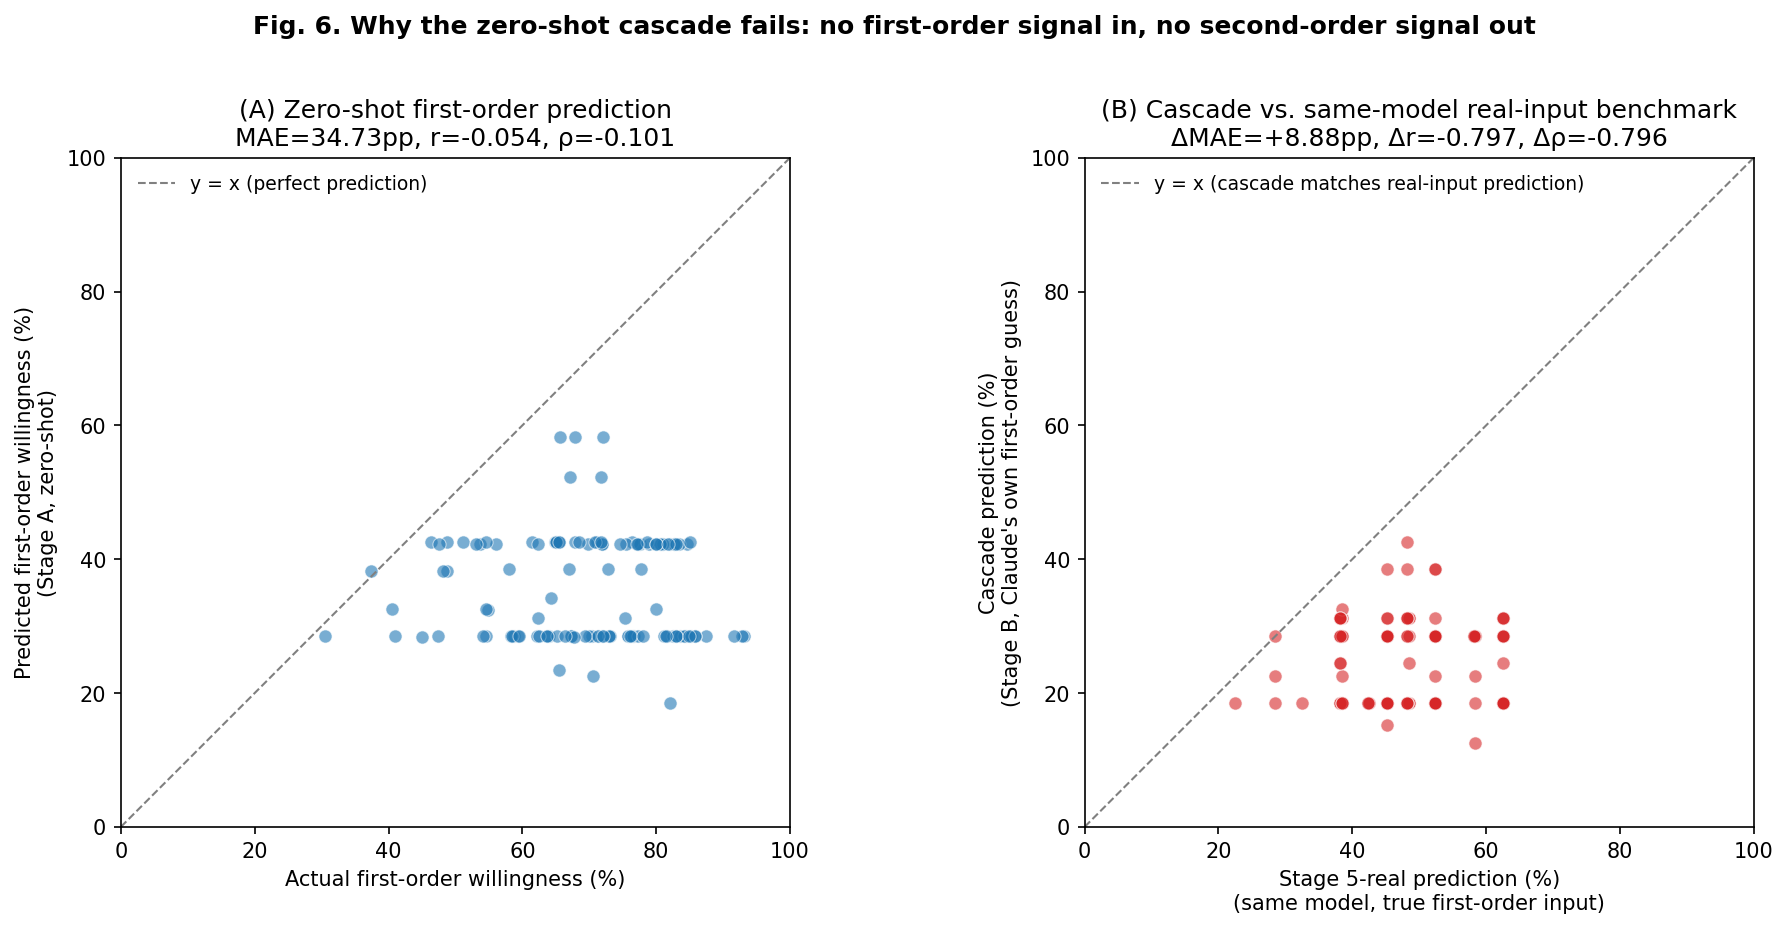

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# Self-contained: loads from disk rather than relying on variables from earlier cells,
# so this cell works even after a kernel restart or if run out of order.
# Requires that Sections 4, 5, 5b, and 6 have been run at least once already
# (so cascade_combined_results.csv exists on disk).
cascade = pd.read_csv("cascade_combined_results.csv")

dA = cascade.dropna(subset=['predicted_own_willingness', 'actual_own_willingness'])
mae_A = (dA['predicted_own_willingness'] - dA['actual_own_willingness']).abs().mean()
r_A, _ = pearsonr(dA['predicted_own_willingness'], dA['actual_own_willingness'])
rho_A, _ = spearmanr(dA['predicted_own_willingness'], dA['actual_own_willingness'])

dB = cascade.dropna(subset=['predicted_other_willingness_cascade', 'actual_other_willingness_pct'])
mae_B = (dB['predicted_other_willingness_cascade'] - dB['actual_other_willingness_pct']).abs().mean()
r_B, _ = pearsonr(dB['predicted_other_willingness_cascade'], dB['actual_other_willingness_pct'])
rho_B, _ = spearmanr(dB['predicted_other_willingness_cascade'], dB['actual_other_willingness_pct'])

d5r = cascade.dropna(subset=['predicted_other_willingness_realFO', 'actual_other_willingness_pct'])
mae_5r = (d5r['predicted_other_willingness_realFO'] - d5r['actual_other_willingness_pct']).abs().mean()
r_5r, _ = pearsonr(d5r['predicted_other_willingness_realFO'], d5r['actual_other_willingness_pct'])
rho_5r, _ = spearmanr(d5r['predicted_other_willingness_realFO'], d5r['actual_other_willingness_pct'])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.set_dpi(150)

# --- Panel A: actual vs. predicted first-order willingness ---
ax = axes[0]
ax.scatter(dA['actual_own_willingness'], dA['predicted_own_willingness'],
           alpha=0.6, s=40, color='#1f77b4', edgecolor='white', linewidth=0.5)
lims = [0, 100]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1, label='y = x (perfect prediction)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual first-order willingness (%)")
ax.set_ylabel("Predicted first-order willingness (%)\n(Stage A, zero-shot)")
ax.set_title(f"(A) Zero-shot first-order prediction\nMAE={mae_A:.2f}pp, r={r_A:.3f}, \u03c1={rho_A:.3f}")
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.set_aspect('equal')

# --- Panel B: cascade vs. Stage 5-real (same model, real first-order input) ---
ax = axes[1]
merged_b = cascade.dropna(subset=['predicted_other_willingness_cascade', 'predicted_other_willingness_realFO'])
ax.scatter(merged_b['predicted_other_willingness_realFO'], merged_b['predicted_other_willingness_cascade'],
           alpha=0.6, s=40, color='#d62728', edgecolor='white', linewidth=0.5)
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1, label='y = x (cascade matches real-input prediction)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Stage 5-real prediction (%)\n(same model, true first-order input)")
ax.set_ylabel("Cascade prediction (%)\n(Stage B, Claude's own first-order guess)")
ax.set_title(f"(B) Cascade vs. same-model real-input benchmark\n\u0394MAE={mae_B-mae_5r:+.2f}pp, \u0394r={r_B-r_5r:+.3f}, \u0394\u03c1={rho_B-rho_5r:+.3f}")
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.set_aspect('equal')

fig.suptitle("Fig. 6. Why the zero-shot cascade fails: no first-order signal in, no second-order signal out",
             fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig("fig6_cascade_validation.pdf", dpi=250, bbox_inches='tight')
plt.show()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=06a315a8-e52a-4232-801d-6bf83a4fef34' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>